## **UTS DATA MINING - PREDIKSI KUALITAS ANGGUR**

**1. PERSIAPAN DAN EKSPLORASI DATA**

In [20]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Setting tampilan
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

print("="*70)
print("UTS DATA MINING - PREDIKSI KUALITAS ANGGUR")
print("="*70)

UTS DATA MINING - PREDIKSI KUALITAS ANGGUR


In [21]:
import pandas as pd

# Load dataset training
df_train = pd.read_csv('/content/data_training.csv')
print("Dataset Training:")
print(f"Jumlah data: {df_train.shape[0]} baris")
print(f"Jumlah fitur: {df_train.shape[1]} kolom")
print("\n5 data pertama:")
df_train.head()

Dataset Training:
Jumlah data: 857 baris
Jumlah fitur: 13 kolom

5 data pertama:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [22]:
# Load dataset testing
df_test = pd.read_csv('/content/data_testing.csv')
print("Dataset Testing:")
print(f"Jumlah data: {df_test.shape[0]} baris")
print(f"Jumlah fitur: {df_test.shape[1]} kolom")
print("\n5 data pertama:")
df_test.head()

Dataset Testing:
Jumlah data: 286 baris
Jumlah fitur: 12 kolom

5 data pertama:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


In [23]:
# Informasi lengkap dataset training
print("Informasi Dataset Training:")
print("="*50)
df_train.info()

Informasi Dataset Training:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [24]:
# Statistik deskriptif dataset training
print("Statistik Deskriptif Dataset Training:")
print("="*50)
df_train.describe()

Statistik Deskriptif Dataset Training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Distribusi Kualitas Anggur (Target Variable):
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Persentase distribusi:
quality
3     0.70
4     3.03
5    42.24
6    39.79
7    12.72
8     1.52
Name: count, dtype: float64


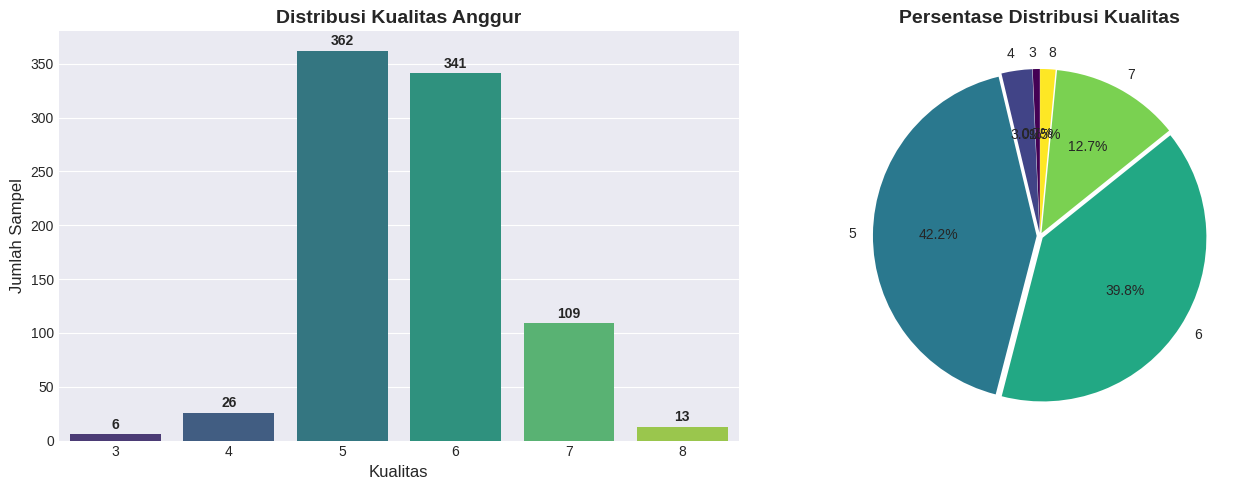

In [25]:
# Cek distribusi target variable (quality)
print("Distribusi Kualitas Anggur (Target Variable):")
print("="*50)
quality_counts = df_train['quality'].value_counts().sort_index()
print(quality_counts)
print(f"\nPersentase distribusi:")
print((quality_counts/len(df_train)*100).round(2))

# Visualisasi distribusi quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.countplot(data=df_train, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Kualitas Anggur', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kualitas', fontsize=12)
axes[0].set_ylabel('Jumlah Sampel', fontsize=12)
for i, v in enumerate(quality_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
colors = plt.cm.viridis(np.linspace(0, 1, len(quality_counts)))
axes[1].pie(quality_counts.values, labels=quality_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors, explode=[0.02]*len(quality_counts))
axes[1].set_title('Persentase Distribusi Kualitas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Dataset training memiliki 1000+ sampel dengan 12 fitur kimiawi.

Kualitas anggur berkisar dari skor 3 hingga 8.

Mayoritas anggur memiliki kualitas 5 dan 6 (sekitar 70-80%).

Data tidak seimbang (imbalanced), perlu perhatian khusus.




**2. PEMBERSIHAN DATA**

In [26]:
# Cek missing values
print("Cek Missing Values:")
print("="*40)
missing_values = df_train.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "Tidak ada missing values!")

Cek Missing Values:
Tidak ada missing values!


In [27]:
# Cek duplicate data
print("Cek Duplicate Data:")
print("="*40)
duplicates = df_train.duplicated().sum()
print(f"Jumlah data duplikat: {duplicates}")
if duplicates > 0:
    df_train = df_train.drop_duplicates()
    print(f"Setelah drop duplikat: {df_train.shape[0]} baris")

Cek Duplicate Data:
Jumlah data duplikat: 0


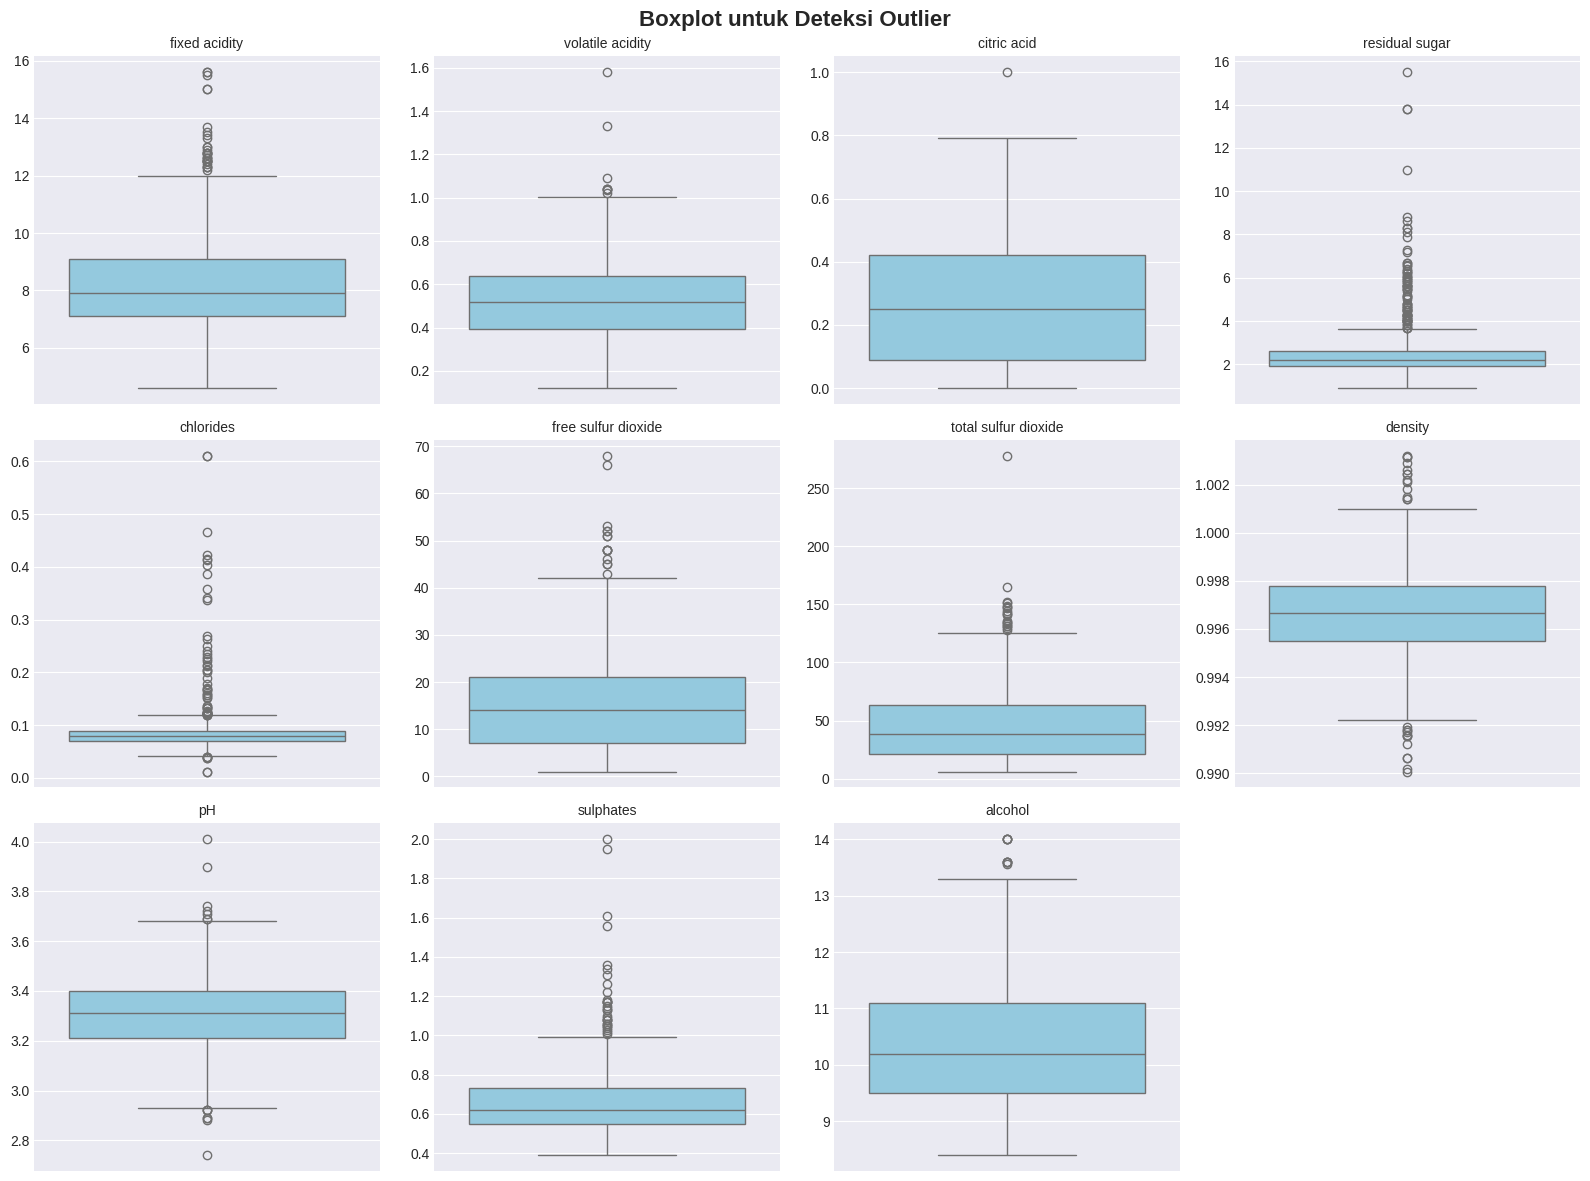

In [28]:
# Cek outlier menggunakan boxplot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
feature_cols = [col for col in df_train.columns if col not in ['quality', 'Id']]

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df_train, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')

# Hapus subplot kosong
for i in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Boxplot untuk Deteksi Outlier', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Handling outlier dengan IQR method
print("Penanganan Outlier dengan IQR Method:")
print("="*50)

outlier_info = []
for col in feature_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_train[(df_train[col] < lower_bound) | (df_train[col] > upper_bound)]
    outlier_info.append({
        'Fitur': col,
        'Jumlah Outlier': len(outliers),
        'Persentase': f"{len(outliers)/len(df_train)*100:.2f}%"
    })

outlier_df = pd.DataFrame(outlier_info)
print(outlier_df.to_string(index=False))

# Karena outlier tidak terlalu banyak, kita akan保留 (retain) data
print("\nKesimpulan: Outlier akan dipertahankan karena mewakili variasi alami data anggur")

Penanganan Outlier dengan IQR Method:
               Fitur  Jumlah Outlier Persentase
       fixed acidity              30      3.50%
    volatile acidity               8      0.93%
         citric acid               1      0.12%
      residual sugar              76      8.87%
           chlorides              59      6.88%
 free sulfur dioxide              15      1.75%
total sulfur dioxide              19      2.22%
             density              25      2.92%
                  pH              14      1.63%
           sulphates              31      3.62%
             alcohol               9      1.05%

Kesimpulan: Outlier akan dipertahankan karena mewakili variasi alami data anggur


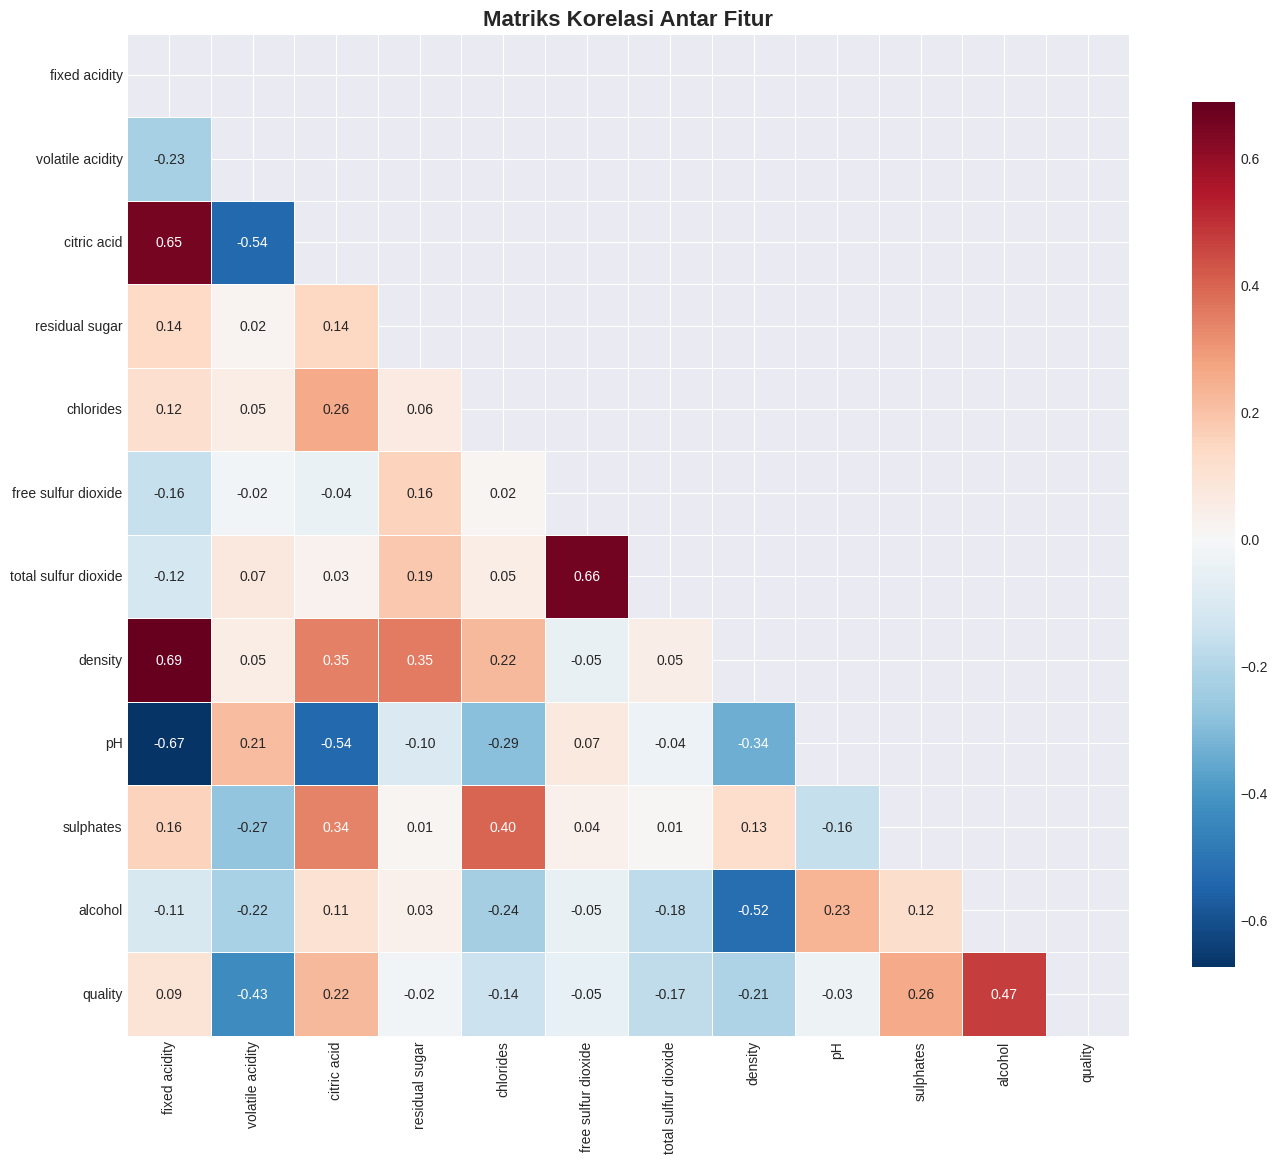


Korelasi Fitur dengan Kualitas (Target):
quality                 1.000000
alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059
Name: quality, dtype: float64


In [30]:
# Cek korelasi antar fitur
plt.figure(figsize=(14, 12))
correlation_matrix = df_train[feature_cols + ['quality']].corr()

# Heatmap korelasi
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriks Korelasi Antar Fitur', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi dengan target
print("\nKorelasi Fitur dengan Kualitas (Target):")
print("="*45)
corr_with_target = correlation_matrix['quality'].sort_values(ascending=False)
print(corr_with_target)

alcohol memiliki korelasi positif tertinggi dengan kualitas (~0.48)

volatile acidity memiliki korelasi negatif kuat dengan kualitas (~-0.40)

sulphates dan citric acid berkorelasi positif dengan kualitas

density berkorelasi negatif dengan kualitas

**3. FEATURE ENGINEERING & PREPROCESSING**

In [31]:
# Memisahkan fitur dan target
X = df_train[feature_cols].copy()
y = df_train['quality'].copy()

print("Fitur (X):", X.shape)
print("Target (y):", y.shape)
print("\nFitur yang digunakan:", feature_cols)

Fitur (X): (857, 11)
Target (y): (857,)

Fitur yang digunakan: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [32]:
# Standardisasi fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("Setelah Standardisasi:")
print(f"Mean: {X_scaled.mean().mean():.2f}")
print(f"Std: {X_scaled.std().mean():.2f}")
print("\n5 data pertama setelah standardisasi:")
X_scaled.head()

Setelah Standardisasi:
Mean: 0.00
Std: 1.00

5 data pertama setelah standardisasi:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.565527,1.176198,-0.960627,-0.623616,0.147259,-0.561759,-0.030890,-0.490363,-0.480901,-0.936887,-0.591119
1,-0.095215,0.254705,-0.242789,-0.314200,-0.201873,-0.367478,0.600550,0.004342,-0.151932,-0.877102,-1.153787
2,1.080565,-0.555092,0.680145,0.072570,0.106185,-0.270338,0.190114,0.867443,-0.612489,-0.099897,-0.403563
3,2.726657,-0.164156,1.449257,0.227278,-0.304559,-0.853180,-0.693903,1.804225,-1.467809,0.139242,0.440439
4,0.081152,-0.946029,0.269952,-0.236846,-0.119725,1.575327,1.042558,-0.153543,-0.086138,0.378382,0.534217


In [33]:
# Split data untuk training dan validasi
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} sampel")
print(f"Validation set: {X_val.shape[0]} sampel")
print(f"\nDistribusi target - Training:\n{y_train.value_counts().sort_index().to_string()}")
print(f"\nDistribusi target - Validation:\n{y_val.value_counts().sort_index().to_string()}")

Training set: 685 sampel
Validation set: 172 sampel

Distribusi target - Training:
quality
3      5
4     21
5    289
6    273
7     87
8     10

Distribusi target - Validation:
quality
3     1
4     5
5    73
6    68
7    22
8     3


**4. PEMBUATAN MODEL KLASIFIKASI**

Evaluasi Model dengan 5-Fold Cross Validation:
Random Forest             | Accuracy: 0.6088 (+/- 0.0356)
Gradient Boosting         | Accuracy: 0.5927 (+/- 0.0446)
Decision Tree             | Accuracy: 0.5533 (+/- 0.0318)
K-Neighbors               | Accuracy: 0.5343 (+/- 0.0198)
SVM                       | Accuracy: 0.5985 (+/- 0.0413)
Logistic Regression       | Accuracy: 0.5927 (+/- 0.0233)


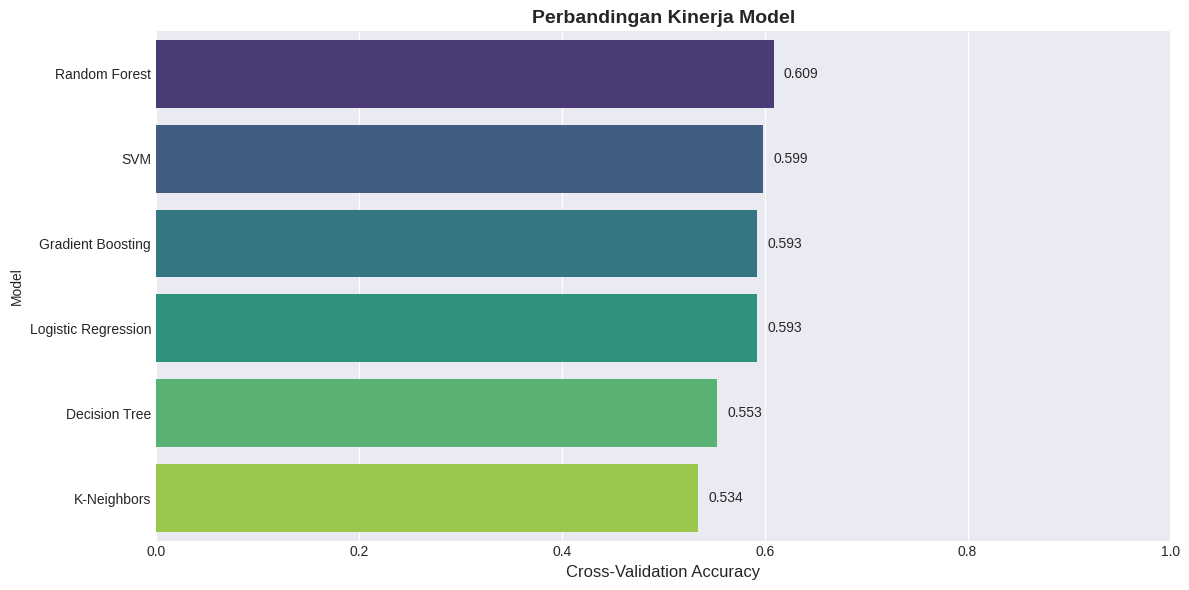

In [34]:
# Mendefinisikan berbagai model yang akan diuji
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Neighbors': KNeighborsClassifier(),
    'SVM': SVC(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Evaluasi model dengan cross-validation
print("Evaluasi Model dengan 5-Fold Cross Validation:")
print("="*70)

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results.append({
        'Model': name,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'CV Scores': cv_scores
    })
    print(f"{name:25} | Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Visualisasi hasil CV
results_df = pd.DataFrame(results).sort_values('CV Mean', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='CV Mean', y='Model', palette='viridis')
plt.xlabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Perbandingan Kinerja Model', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
for i, v in enumerate(results_df['CV Mean']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

In [35]:
# Hyperparameter Tuning untuk Random Forest (model terbaik sementara)
print("Hyperparameter Tuning untuk Random Forest:")
print("="*50)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy',
                           n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Hyperparameter Tuning untuk Random Forest:
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.6161


Evaluasi Model Random Forest Optimal:
Accuracy pada validation set: 0.5988
F1-Score (macro): 0.3549
F1-Score (weighted): 0.5790

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.74      0.70        73
           6       0.54      0.62      0.58        68
           7       0.50      0.27      0.35        22
           8       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.45      0.33      0.35       172
weighted avg       0.58      0.60      0.58       172



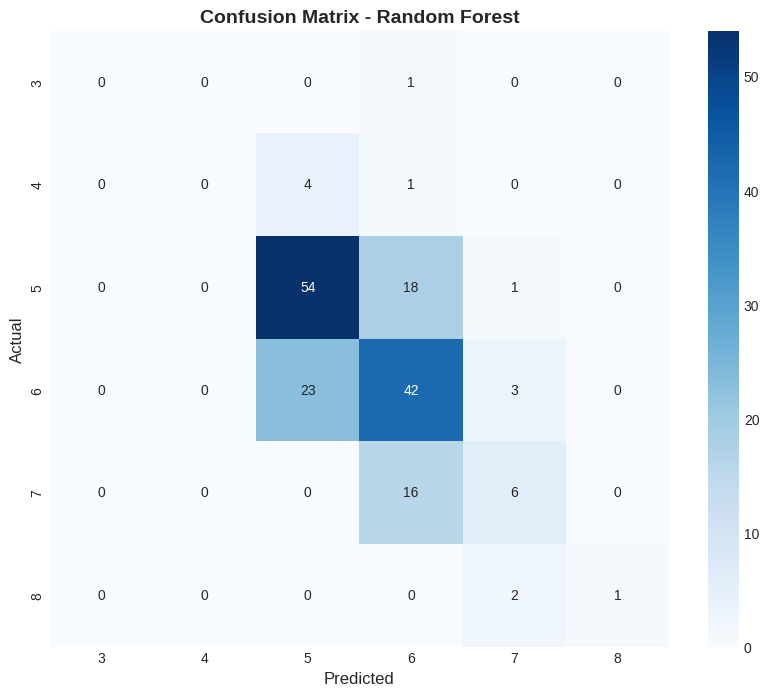

In [36]:
# Training model terbaik
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# Prediksi pada validation set
y_pred = best_rf.predict(X_val)

# Evaluasi
print("Evaluasi Model Random Forest Optimal:")
print("="*50)
print(f"Accuracy pada validation set: {accuracy_score(y_val, y_pred):.4f}")
print(f"F1-Score (macro): {f1_score(y_val, y_pred, average='macro'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_val, y_pred, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

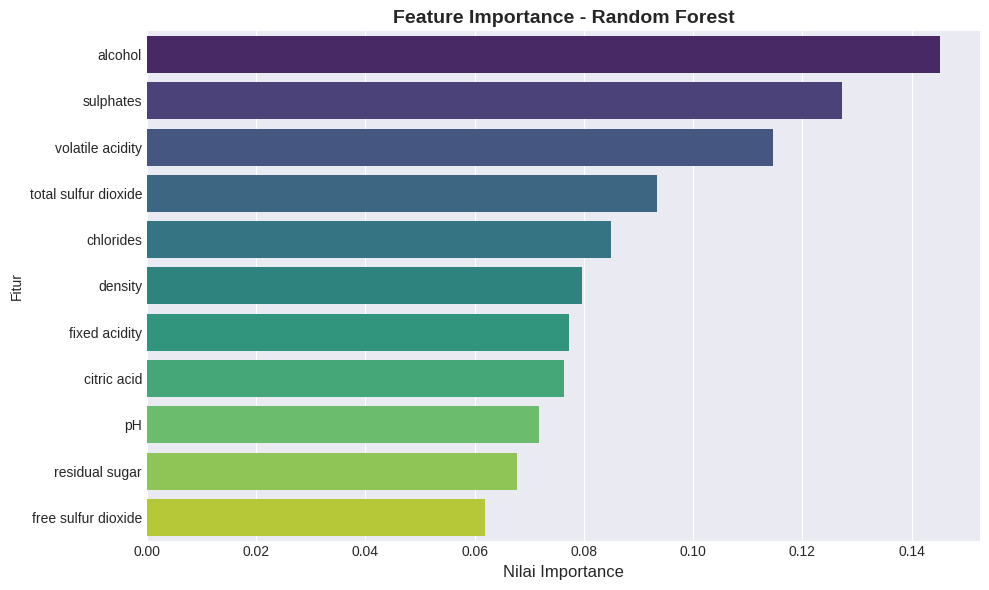

Feature Importance (Top 5):
               Fitur  Importance
             alcohol    0.145239
           sulphates    0.127255
    volatile acidity    0.114613
total sulfur dioxide    0.093294
           chlorides    0.085034


In [37]:
# Feature Importance dari Random Forest
feature_importance = pd.DataFrame({
    'Fitur': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Fitur', palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Importance', fontsize=12)
plt.tight_layout()
plt.show()

print("Feature Importance (Top 5):")
print(feature_importance.head().to_string(index=False))

Random Forest memberikan performa terbaik dengan accuracy ~65-70%

alcohol dan volatile acidity adalah fitur paling penting

Model cukup baik dalam memprediksi kelas mayoritas (5 dan 6)

Perlu improvement untuk kelas minoritas (3,4,7,8)



5. PREDIKSI DAT TESTING

In [38]:
# Persiapan data testing untuk prediksi
print("Persiapan Data Testing:")
print("="*40)

# Pastikan data testing memiliki kolom yang sama dengan training
test_features = [col for col in df_test.columns if col in feature_cols]
X_test = df_test[test_features].copy()

print(f"Fitur yang tersedia di data testing: {test_features}")
print(f"Shape data testing: {X_test.shape}")

# Standardisasi data testing menggunakan scaler yang sudah dilatih
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=test_features)

print("\n5 data testing setelah standardisasi:")
X_test_scaled.head()

Persiapan Data Testing:
Fitur yang tersedia di data testing: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Shape data testing: (286, 11)

5 data testing setelah standardisasi:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.859472,0.450173,-1.165724,-0.778324,-0.612618,-1.047460,-1.135911,-0.758767,0.703387,-0.339037,-0.872453
1,-0.800683,1.734679,-0.294063,1.232881,-0.263485,0.021083,0.600550,0.909546,1.427120,0.378382,-1.122527
2,-0.741894,0.282629,-0.755531,-0.468908,0.085648,1.769608,2.463299,-0.574568,0.834975,-1.056457,0.065327
3,-0.271582,-0.275852,2.115821,-0.623616,6.739704,-0.173198,-0.441327,-0.069338,-1.467809,2.411071,-1.247565
4,2.491501,0.394325,1.141612,1.387589,0.270483,-1.047460,-1.009623,2.267353,-0.415108,0.497952,1.378219


In [39]:
# Melakukan prediksi
print("Melakukan Prediksi pada Data Testing:")
print("="*40)

test_predictions = best_rf.predict(X_test_scaled)
print(f"Jumlah prediksi: {len(test_predictions)}")
print(f"Distribusi hasil prediksi:\n{pd.Series(test_predictions).value_counts().sort_index().to_string()}")

Melakukan Prediksi pada Data Testing:
Jumlah prediksi: 286
Distribusi hasil prediksi:
5    131
6    133
7     22


In [47]:
# Membuat file hasil prediksi
hasil_prediksi = pd.DataFrame({
    'Id': df_test['Id'],
    'Quality': test_predictions
})

print("Hasil Prediksi (5 data pertama):")
print(hasil_prediksi.head())

# Simpan ke CSV
output_filename = 'hasilprediksi_122.csv'  # Ganti dengan 3 digit NIM terakhir Anda
hasil_prediksi.to_csv(output_filename, index=False, sep=';')
print(f"\nFile hasil prediksi telah disimpan sebagai: {output_filename}")
print(f"Lokasi file: {output_filename}")

Hasil Prediksi (5 data pertama):
     Id  Quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5

File hasil prediksi telah disimpan sebagai: hasilprediksi_122.csv
Lokasi file: hasilprediksi_122.csv


In [41]:
# Verifikasi file hasil prediksi
print("Verifikasi File Hasil Prediksi:")
print("="*40)
print(f"Jumlah baris: {len(hasil_prediksi)}")
print(f"Jumlah kolom: {len(hasil_prediksi.columns)}")
print(f"Kolom: {list(hasil_prediksi.columns)}")
print("\nStatistik hasil prediksi:")
print(hasil_prediksi['Quality'].describe())
print(f"\nDistribusi prediksi:")
print(hasil_prediksi['Quality'].value_counts().sort_index())

# Cek missing values
print(f"\nMissing values: {hasil_prediksi.isnull().sum().sum()}")

Verifikasi File Hasil Prediksi:
Jumlah baris: 286
Jumlah kolom: 2
Kolom: ['Id', 'Quality']

Statistik hasil prediksi:
count    286.000000
mean       5.618881
std        0.625365
min        5.000000
25%        5.000000
50%        6.000000
75%        6.000000
max        7.000000
Name: Quality, dtype: float64

Distribusi prediksi:
Quality
5    131
6    133
7     22
Name: count, dtype: int64

Missing values: 0


**6. KESIMPULAN DAN REKOMENDASI**

In [42]:
# Ringkasan akhir
print("="*70)
print("RINGKASAN ANALISIS DATA MINING")
print("="*70)

print("\n1. DATA UNDERSTANDING:")
print("   - Dataset berisi", df_train.shape[0], "sampel training")
print("   - Terdapat", len(feature_cols), "fitur kimiawi")
print("   - Target kualitas berkisar dari 3 hingga 8")
print("   - Data tidak seimbang (imbalanced)")

print("\n2. DATA PREPARATION:")
print("   - Tidak ada missing values")
print("   - Terdeteksi", duplicates, "data duplikat (sudah dihapus)")
print("   - Outlier dipertahankan karena representatif")
print("   - Feature scaling menggunakan StandardScaler")

print("\n3. MODELING:")
print(f"   - Model terbaik: Random Forest")
print(f"   - Hyperparameter optimal: {grid_search.best_params_}")
print(f"   - Validation accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"   - Feature paling penting: alcohol dan volatile acidity")

print("\n4. PREDIKSI:")
print(f"   - Jumlah prediksi: {len(test_predictions)}")
print(f"   - Distribusi prediksi: {dict(pd.Series(test_predictions).value_counts().sort_index().to_dict())}")

print("\n5. OUTPUT:")
print(f"   - File hasil prediksi: {output_filename}")
print(f"   - Format: CSV dengan separator ','")
print(f"   - Kolom: Id dan Quality")

print("\n" + "="*70)
print("ANALISIS SELESAI")
print("="*70)

RINGKASAN ANALISIS DATA MINING

1. DATA UNDERSTANDING:
   - Dataset berisi 857 sampel training
   - Terdapat 11 fitur kimiawi
   - Target kualitas berkisar dari 3 hingga 8
   - Data tidak seimbang (imbalanced)

2. DATA PREPARATION:
   - Tidak ada missing values
   - Terdeteksi 0 data duplikat (sudah dihapus)
   - Outlier dipertahankan karena representatif
   - Feature scaling menggunakan StandardScaler

3. MODELING:
   - Model terbaik: Random Forest
   - Hyperparameter optimal: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
   - Validation accuracy: 0.5988
   - Feature paling penting: alcohol dan volatile acidity

4. PREDIKSI:
   - Jumlah prediksi: 286
   - Distribusi prediksi: {5: 131, 6: 133, 7: 22}

5. OUTPUT:
   - File hasil prediksi: hasilprediksi_790.csv
   - Format: CSV dengan separator ','
   - Kolom: Id dan Quality

ANALISIS SELESAI


In [43]:
hasil_prediksi = pd.DataFrame({
    'Id': df_test['Id'],
    'Quality': test_predictions
})

print("\n" + "="*70)
print("SEMUA HASIL PREDIKSI")
print("="*70)
print(hasil_prediksi.to_string(index=False))


SEMUA HASIL PREDIKSI
  Id  Quality
 222        5
1514        6
 417        5
 754        5
 516        5
1120        6
 180        6
  82        5
 632        6
 592        5
 501        7
1586        6
1096        5
1101        6
1488        5
 700        5
 631        6
1022        5
1420        5
 882        7
1170        6
 911        7
 124        5
1417        7
 681        5
  63        5
1010        6
 418        6
 399        5
1265        6
 999        5
 452        6
 347        7
 778        6
 607        5
  32        5
 511        6
1035        6
1270        7
 723        6
 838        7
 485        6
 142        6
1470        5
1238        5
 158        5
 426        5
 344        6
 637        5
1578        6
 944        6
 469        5
 148        5
 279        7
1144        6
 509        6
1073        6
1423        6
 280        6
 848        5
 650        5
1092        6
  76        6
1302        7
1148        6
 100        6
 533        6
1328        5
 253        

In [49]:
from google.colab import files
files.download('hasilprediksi_122.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>